# Habitat suitability under climate change

Our changing climate is changing where plant species can live,
and conservation and restoration practices will need to take
this into
account.

In this coding challenge, you will create a habitat suitability model
for a terrestrial plant species of your choice that lives in the contiguous United States
(CONUS). We have this limitation because the downscaled climate data we
suggest, the [MACAv2 dataset](https://www.climatologylab.org/maca.html),
is only available in the CONUS – if you find other downscaled climate
data at an appropriate resolution, you are welcome to choose a different
study area. If you don’t have anything in mind, you can take a look at
[*Sorghastrum nutans*](https://www.gbif.org/species/2704414), a grass native to North America. In the past 50
years, its range has moved
northward.

Your suitability assessment will be based on combining multiple data
layers related to soil, topography, and climate, then applying a fuzzy logic model across the different data layers to generate habitat suitability maps. 

You will need to create a **modular, reproducible, workflow** using functions and loops.
To do this effectively, we recommend planning your code out in advance
using a technique such as a pseudocode outline or a flow diagram. We
recommend breaking each of the blocks below out into multiple steps. It
is unnecessary to write a step for every line of code unless you find
that useful. As a rule of thumb, aim for steps that cover the major
structures of your code in 2-5 line chunks.

## STEP 0: Packages

In [312]:
### reprodecable file paths
import os
from glob import glob
import pathlib
from pathlib import Path

### gbif packages
import pygbif.occurrences as occ
import pygbif.species as species 
from getpass import getpass 

### unzipping files
import zipfile
import time 

### spatial data handling
import geopandas as gpd
import xrspatial

### data types
import numpy as np
import pandas as pd 
import rioxarray as rxr 
import rioxarray.merge as rxrm

### imnvalid geometry handling
from shapely.geometry import MultiPolygon, Polygon
import hvplot.pandas
import hvplot.xarray

### for api use 
import requests

import fiona
from math import floor, ceil   
import matplotlib.pyplot as plt

import earthaccess

from tqdm.notebook import tqdm
import xarray as xr

## STEP 1: Study overview

Before you begin coding, you will need to design your study.

### Step 1a: Select a species
Select the terrestrial plant species you want to study, and research its habitat parameters in scientific studies or other reliable sources. Individual studies may not have the breadth needed for this purpose, so take a look at reviews or overviews of the data. Do **not** just look at an AI-generated summary! In the US, the National Resource Conservation Service can have helpful fact sheets about different species. University Extension programs are also good resources for summaries.</p>
<p>Based on your research, select soil, topographic, and climate variables that you can use to determine if a particular location and time period is a suitable habitat for your species.</p></div></div>

**Reflect and respond**: 
Write a description of your species. What habitat is it found in? What is its geographic range? What, if any, are conservation threats to the species? What data will shed the most light on habitat suitability for this species? 

What core scientific question do you hope to answer about potential future changes in habitat suitability? Don't forget to cite your sources!

Your response here:

I have decided on the above suggestion and am focusing on Sorghastrum nutans which is also called Indiangrass or Yellow Indiangrass. 

Sorghastrum nutans is found from Quebec and Maine west to central Saskatchewan, south to Arizona and northern Mexico, and east to Florida. It is found in all but 5 of the 48 continental states.
it commonly inhabits prairies, open woodlands, savannas, and roadsides. It thrives in well-drained soils but can tolerate a range of soil textures, from sandy to clay loams.

Indiangrass typically grows between 3 to 8 feet (0.9–2.4 meters) tall, with flowering stalks often reaching the upper end of that range.
Its altitude (elevation) range in the United States extends from sea level up to approximately 7,500 feet (about 2,300 meters), depending on regional conditions.

Sorghastrum nutans tolerates a soil pH range of approximately 5 to 7.8, preferring slightly acidic to neutral soils but showing adaptability to mildly alkaline conditions.
In additon, i totlerates precipitation ranges from approcimately 12 to 40 inches of annual rainfall and its root depth (minimum) is 24 inces. 

Core scientic question: Indiangrass appears to be a very resilient plant in itself. However, the question arises as to how far its spread will be affected by changes in temperature and precipitation due to climate change.

References: 

Walkup, Crystal J. 1991. Sorgastrum nutans. In: Fire Effects Information System, [Online]. 
U.S. Department of Agriculture, Forest Service, Rocky Mountain Research Station, 
Fire Sciences Laboratory (Producer). Available: 
https://www.fs.usda.gov/database/feis/plants/graminoid/sornut/all.html [2026, March 3]

https://plants.usda.gov/plant-profile/SONU2/characteristics

https://extension.usu.edu/rangeplants/grasses-and-grasslikes/indiangrass





### File paths settings

We first have a look at the Global Biodiversity Information Facility site

In [2]:
### file paths 
data_dir = os.path.join(
    pathlib.Path.home(), 
    'earth-analytics',
    'data',
    'habitat_suit'                    
)
os.makedirs(data_dir, exist_ok=True)

In [3]:
### gbif data dir
gbif_dir = os.path.join(
    data_dir,
    'gbif_indiangrass'
)

In [4]:
### gbif login credentials
reset_credentials = False

### make dictionary for gbif credentials
credentials = dict(
    
    GBIF_USER = (input, 'GBIF username'),
    GBIF_PWD = (getpass, 'GBIF password'),
    GBIF_EMAIL = (input, 'GBIF email'),
)

### loop through credentials and get user input
for env_variable, (prompt_func, prompt_text) in credentials.items():
    if reset_credentials and (env_variable in os.environ):
        os.environ.pop(env_variable)
    if not env_variable in os.environ:
        os.environ[env_variable] = prompt_func(prompt_text)

In [5]:
### species name 
species_name = 'Sorghastrum nutans'

### species infos from gbif 
species_info_1 = species.name_backbone(name=species_name)
species_info_2 = species.name_lookup(name=species_name, rank='species')

In [6]:
species_info_1

{'usageKey': 2704414,
 'scientificName': 'Sorghastrum nutans (L.) Nash',
 'canonicalName': 'Sorghastrum nutans',
 'rank': 'SPECIES',
 'status': 'ACCEPTED',
 'confidence': 99,
 'matchType': 'EXACT',
 'kingdom': 'Plantae',
 'phylum': 'Tracheophyta',
 'order': 'Poales',
 'family': 'Poaceae',
 'genus': 'Sorghastrum',
 'species': 'Sorghastrum nutans',
 'kingdomKey': 6,
 'phylumKey': 7707728,
 'classKey': 196,
 'orderKey': 1369,
 'familyKey': 3073,
 'genusKey': 2704413,
 'speciesKey': 2704414,
 'class': 'Liliopsida'}

For some reason, the command "species.name_lookup(name=species_name, rank='species')" dies not lead to the right species (with the same species name), but always to Caldisphaera lagunensis.
I will rely on "species.name_backbone(name=species_name)"

In [7]:
species_info_2['results'][0]

{'key': 1000003,
 'nameKey': 1800983,
 'datasetKey': 'd7dddbf4-2cf0-4f39-9b2a-bb099caae36c',
 'constituentKey': 'a97f36e5-ded1-49cc-bdec-ac6170fc7b9c',
 'nubKey': 1000003,
 'parentKey': 1000002,
 'parent': 'Caldisphaera',
 'kingdom': 'Archaea',
 'phylum': 'Thermoproteota',
 'order': 'Sulfolobales',
 'family': 'Acidilobaceae',
 'genus': 'Caldisphaera',
 'species': 'Caldisphaera lagunensis',
 'kingdomKey': 2,
 'phylumKey': 10807497,
 'classKey': 10705623,
 'orderKey': 564,
 'familyKey': 5900544,
 'genusKey': 1000002,
 'speciesKey': 1000003,
 'scientificName': 'Caldisphaera lagunensis Itoh et al., 2003',
 'canonicalName': 'Caldisphaera lagunensis',
 'authorship': 'Itoh et al., 2003',
 'publishedIn': 'Int. J. Syst. Evol. Microbiol. 53::1153',
 'nameType': 'SCIENTIFIC',
 'taxonomicStatus': 'ACCEPTED',
 'rank': 'SPECIES',
 'origin': 'SOURCE',
 'numDescendants': 0,
 'numOccurrences': 0,
 'taxonID': 'gbif:1000003',
 'extinct': False,
 'habitats': [],
 'nomenclaturalStatus': [],
 'threatStatuse

In [8]:
species_key = species_info_1['speciesKey']
species_info_1['species'], species_key

('Sorghastrum nutans', 2704414)

In [9]:
### assigne species code 
species_key = 2704414

In [10]:
### make a filepath
gbif_pattern = os.path.join(
    gbif_dir,
    '*.csv'
)

### download it once
if not glob(gbif_pattern):

    ### sumit a download request to the gbif api
    gbif_query = occ.download([
            f"speciesKey = {species_key}",
            "hasCoordinate = True",
        ])

    ### only dowload once 
    if not 'GBIF_DOWNLOAD_KEY' in os.environ:
        os.environ['GBIF_DOWNLOAD_KEY'] = gbif_query[0]
        download_key = os.environ['GBIF_DOWNLOAD_KEY']

        ### wait for the download to build 
        wait = occ.download_meta(download_key)['status']
        while not wait == 'SUCCEEDED':
            wait = occ.download_meta(download_key)['status']
            time.sleep(5)

    ### dowloand data
    download_info = occ.download_get(
        os.environ['GBIF_DOWNLOAD_KEY'], 
        path=data_dir
    )

    ### unizip the downloaded file
    with zipfile.ZipFile(download_info['path']) as download_zip:
        download_zip.extractall(path = gbif_dir)   


INFO:Your download key is 0013699-260226173443078
INFO:Download file size: 1445649 bytes
INFO:On disk at /Users/markusjesswein/earth-analytics/data/habitat_suit/0013699-260226173443078.zip


In [13]:
### find csv file in the gbif dir
gbif_path = glob(gbif_pattern)[0]
gbif_path

'/Users/markusjesswein/earth-analytics/data/habitat_suit/gbif_indiangrass/0013699-260226173443078.csv'

In [14]:
gbif_df = pd.read_csv(gbif_path,
                      delimiter='\t'
                      )

gbif_df.head()

/var/folders/_9/rlrj6gw54653j66jwjb_srb00000gn/T/ipykernel_54169/1043720972.py:1: DtypeWarning: Columns (10,46) have mixed types. Specify dtype option on import or set low_memory=False.
  gbif_df = pd.read_csv(gbif_path,


,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,91854558,85802736-f762-11e1-a439-00145eb45e9a,NaN,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,NaN,NaN,CC_BY_4_0,NaN,NaN,NaN,NaN,2026-02-20T05:24:16.614Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...
1,899968435,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/625779,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,John Davis,2014-04-15T14:53:58,CC_BY_NC_4_0,John Davis,John Davis,NaN,NaN,2026-02-24T00:03:54.613Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...
2,899942318,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/397146,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,Erin Haase,2013-09-14T15:19:58,CC_BY_NC_4_0,Erin Haase,Erin Haase,NaN,NaN,2026-02-24T00:03:59.388Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
3,891779719,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/492905,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,botanygirl,2014-01-04T02:07:53,CC_BY_4_0,botanygirl,botanygirl,NaN,NaN,2026-02-24T00:03:54.394Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...
4,891779064,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/491471,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,Erin Haase,2014-01-01T22:57:29,CC_BY_NC_4_0,Erin Haase,Erin Haase,NaN,NaN,2026-02-23T22:51:28.870Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...


In [16]:
### make it geopandas dataframe
gbif_gdf = (
    gpd.GeoDataFrame(gbif_df, 
                            geometry=gpd.points_from_xy(
                                gbif_df.decimalLongitude, 
                                gbif_df.decimalLatitude),
                            crs='EPSG:4326'
                            )
                            )

gbif_gdf

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue,geometry
0,91854558,85802736-f762-11e1-a439-00145eb45e9a,NaN,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,NaN,CC_BY_4_0,NaN,NaN,NaN,NaN,2026-02-20T05:24:16.614Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...,POINT (-83.19139 40.54833)
1,899968435,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/625779,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2014-04-15T14:53:58,CC_BY_NC_4_0,John Davis,John Davis,NaN,NaN,2026-02-24T00:03:54.613Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-97.9635 31.3983)
2,899942318,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/397146,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2013-09-14T15:19:58,CC_BY_NC_4_0,Erin Haase,Erin Haase,NaN,NaN,2026-02-24T00:03:59.388Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-87.78014 42.00261)
3,891779719,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/492905,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2014-01-04T02:07:53,CC_BY_4_0,botanygirl,botanygirl,NaN,NaN,2026-02-24T00:03:54.394Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-76.32274 38.99236)
4,891779064,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/491471,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2014-01-01T22:57:29,CC_BY_NC_4_0,Erin Haase,Erin Haase,NaN,NaN,2026-02-23T22:51:28.870Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-87.83164 42.14056)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18132,1024219740,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/857978,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2014-09-01T23:44:23,CC_BY_4_0,aarongunnar,aarongunnar,NaN,NaN,2026-02-23T21:45:10.385Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (-91.10712 46.19856)
18133,1024218991,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/856098,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2014-08-31T20:44:48,CC_BY_NC_4_0,Ben VanderWeide,Ben VanderWeide,NaN,NaN,2026-02-24T00:03:58.883Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-84.64363 44.64928)
18134,1024215559,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/846941,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2014-08-25T04:20:03,CC_BY_4_0,aarongunnar,aarongunnar,NaN,NaN,2026-02-23T21:44:54.590Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-91.01188 44.70558)
18135,1024213350,50c9509d-22c7-4a22-a47d-8c48425ef4a7,http://www.inaturalist.org/observations/841380,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Sorghastrum,Sorghastrum nutans,...,2014-08-21T17:34:35,CC_BY_4_0,aarongunnar,aarongunnar,NaN,NaN,2026-02-23T22:51:27.566Z,StillImage,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NO...,POINT (-91.84786 44.73288)


In [17]:
### plit it 
gbif_gdf.hvplot(
    #x='decimalLongitude', 
    #y='decimalLatitude', 
    geo=True, 
    tiles='EsriImagery',
    title='Sorghastrum nutans occurrences in GBIF',
    line_color='yellow',
    frame_width=500,
    frame_height=500
)

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]

The occurencence data in GBIF confirms the distribution given in thge literature of Indiangrass. 


### Step 1b: Select study sites
Based on your research and/or range maps you find online, select at least 2 sites where your species occurs. These could be national parks, national forests, national grasslands or other protected areas, or some other area you're interested in. You can access protected area polygons from the [US Geological Survey's Protected Area Database](https://www.usgs.gov/programs/gap-analysis-project/science/pad-us-data-overview), [national grassland units](https://data.fs.usda.gov/geodata/edw/edw_resources/shp/S_USA.NationalGrassland.zip), etc.

When selecting your sites, you might want to look for places that are marginally habitable for this species, since those locations will be most likely to show changes due to climate.

Generate a site map for each location.

In [ ]:
class SciencebaseSite():
    """
    A class to handle the downloading, unzipping, and processing of government layers from ScienceBase for a specific site."""

    def __init__(self, site_dir_name ,filename):
        """
        Initialize the SciencebaseSite instance.
        site_dir_name: The name of the directory for the site (e.g., "indiangrass_CO").
        filename: The name of the file to download (e.g., "PADUS4_1_State_CO_GDB_KMZ.zip").
        """

        self.site_name = site_dir_name[-2:]  # Extract last two characters (e.g., "CO")
        self.item_id = "6759abcfd34edfeb8710a004"
        self.filename = filename

        # Create directory per instance (safer)
        self.site_dir = Path(data_dir) / site_dir_name # "indiangrass_sites"
        self.site_dir.mkdir(parents=True, exist_ok=True)

        self.url = (
            f"https://www.sciencebase.gov/catalog/file/get/"
            f"{self.item_id}?name={self.filename}"
        )
        # this will be the path to the downloaded file, set after download
        self.file_output_path = None

        ### thse methods are executed in the initialization, but you can call them separately if needed
        self.download()
        self.unzip()


    def download(self):
        """
        Download the file from ScienceBase and save it to the site directory.
        """
        response = requests.get(self.url)
        if response.status_code == 200:
            self.file_output_path = self.site_dir / self.filename
            with open(self.file_output_path, 'wb') as f:
                f.write(response.content)
            print(f"Downloaded {self.filename} to {self.file_output_path}")

        else:
            print(f"Failed to download {self.filename}. Status code: {response.status_code}")
    

    def unzip(self):
        """
        Unzip the downloaded file if it's a zip archive.
        """
        ### place for unzipped file is the same as the zipped file 
        zip_path = Path(self.file_output_path)

        extract_folder = zip_path.parent
        extract_folder.mkdir(parents=True, exist_ok=True)

        ### unzip the file
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)
        print(f"Unzipped {self.filename} to {extract_folder}")


    def get_gov_layers(self):
        """
        Get the FEE layers
        """
        ### path to the gdb file
        pa_path = self.site_dir / f"PADUS4_1_State{self.site_name}.gdb"

        ### read the fee layer
        self.pa_shp = gpd.read_file(pa_path, layer= f"PADUS4_1Fee_State_{self.site_name}")

        ### change the crs to match the gbif data
        self.pa_shp = self.pa_shp.to_crs('EPSG:4326')

        ### fix invalid geometries
        self.pa_shp['geometry'] = self.pa_shp['geometry'].apply(
            lambda geom: geom.make_valid() if not isinstance(geom, MultiPolygon) and not geom.is_valid else geom
        )
        ### drop remaining invalid geometries
        self.pa_shp = self.pa_shp[self.pa_shp.geometry.is_valid]

        ### missing geometries
        self.pa_shp = self.pa_shp.dropna(subset=['geometry'])

        print(f"Loaded and processed government layers for {self.site_name}")


    def get_intersect_with_gbif(self, gbif_gdf):
        """
        Get the intersection of the government layers with the GBIF occurrences.
        """
        if hasattr(self, 'pa_shp'):
            self.gbif_intersection = gpd.overlay(gbif_gdf, self.pa_shp, how='intersection')
            self.gbif_intersection_count = self.gbif_intersection['Loc_Nm'].value_counts()
            print(f"Calculated intersection of government layers with GBIF occurrences for {self.site_name}")
        else:
            print("Government layers not loaded. Please run get_gov_layers() first.")


    def plot_gov_layers(self):
        """
        Plot the government layers using hvplot.
        """
        if hasattr(self, 'pa_shp'):
            self.pa_shp.hvplot(
                geo=True, 
                tiles='EsriImagery',
                title=f'Government Layers for {self.site_name}',
                line_color='blue',
                frame_width=500,
                frame_height=500
            )
        else:
            print("Government layers not loaded. Please run get_gov_layers() first.")

### Fist site in Wisconsin

In [66]:
### create instances for both sites, starting with wisconsin
wisconsin_IG = SciencebaseSite(site_dir_name='indiangrass_WI', filename="PADUS4_1_State_WI_GDB_KMZ.zip")

Downloaded PADUS4_1_State_WI_GDB_KMZ.zip to /Users/markusjesswein/earth-analytics/data/habitat_suit/indiangrass_WI/PADUS4_1_State_WI_GDB_KMZ.zip
Unzipped PADUS4_1_State_WI_GDB_KMZ.zip to /Users/markusjesswein/earth-analytics/data/habitat_suit/indiangrass_WI


In [67]:
### get government layers
wisconsin_IG.get_gov_layers()
### get intersection with gbif data
wisconsin_IG.get_intersect_with_gbif(gbif_gdf)

Loaded and processed government layers for WI
Calculated intersection of government layers with GBIF occurrences for WI


In [76]:
wisconsin_IG.gbif_intersection_count

Loc_Nm
Uw Arboretum                                    53
Kettle Moraine State Forest-Lapham Peak Unit    26
Owen Conservation Park                          23
Natural Area                                    22
Spring Green Preserve                           16
                                                ..
Sunset Park & Pool                               1
Trenton Bluff Prairie State Natural Area         1
Winnebago County Park                            1
Dawley Conservation Park                         1
Dunnville Wildlife Area                          1
Name: count, Length: 186, dtype: int64

In [141]:
### get gdf for richard bong recreation area
richard_bong_gdf = wisconsin_IG.pa_shp[wisconsin_IG.pa_shp['Loc_Nm'] == 'Richard Bong Recreation Area']

In [143]:
### plot the government layers for richard bong recreation area
richard_bong_gdf.hvplot(
                geo=True, 
                tiles='EsriImagery',
                title='Richard Bong Recreation Area',
                line_color='blue',
                frame_width=500,
                frame_height=500
            )

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

### Second site in Texas

In [83]:
### create instance for texas
texas_IG = SciencebaseSite(site_dir_name='indiangrass_TX', filename="PADUS4_1_State_TX_GDB_KMZ.zip")

Downloaded PADUS4_1_State_TX_GDB_KMZ.zip to /Users/markusjesswein/earth-analytics/data/habitat_suit/indiangrass_TX/PADUS4_1_State_TX_GDB_KMZ.zip
Unzipped PADUS4_1_State_TX_GDB_KMZ.zip to /Users/markusjesswein/earth-analytics/data/habitat_suit/indiangrass_TX


In [84]:
### get government layers
texas_IG.get_gov_layers()
### get intersection with gbif data
texas_IG.get_intersect_with_gbif(gbif_gdf)

Loaded and processed government layers for TX
Calculated intersection of government layers with GBIF occurrences for TX


In [85]:
texas_IG.gbif_intersection_count

Loc_Nm
MEMORIAL PARK                                   85
Fort Worth Nature Center And Wildlife Refuge    83
LEWISVILLE                                      82
Tandy Hills Nature Area                         58
Heard Science Museum and Sanctuary              57
                                                ..
CANYON                                           1
Lakeside Marina                                  1
Lyndon B. Johnson                                1
Caddo National Grassland WMA- Ladonia Unit       1
Chuck Silcox Park                                1
Name: count, Length: 310, dtype: int64

In [473]:
### get gdf for indiangrass wildlife sanctuary
#i_grass_wildlife_gdf = texas_IG.pa_shp[texas_IG.pa_shp['Loc_Nm'] == 'Indiangrass Wildlife Sanctuary']
balcones_canyonlands_gdf = texas_IG.pa_shp[texas_IG.pa_shp['Loc_Nm'] == 'BALCONES CANYONLANDS NATIONAL WILDLIFE REFUGE']

In [474]:
### plot the government layers for indiangrass wildlife sanctuary
balcones_canyonlands_gdf.hvplot(
                geo=True, 
                tiles='EsriImagery',
                title='Balcones Canyonlands National Wildlife Refuge',
                line_color='blue',
                frame_width=500,
                frame_height=500
            )

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [ ]:
### combined into sigle gdf 
#sites_gdf = gpd.GeoDataFrame(pd.concat([site_a_gdf, site_b_gdf], ignore_index=True))

**Reflect and Respond**: 
Write a site description for each of your sites, or for all of your sites as a group if you have chosen a large number of linked sites. What
differences or trends in habitat suitability over time do you expect to see among your sites?

### Step 1c: Select time periods

In general when studying climate, we are interested in **climate
normals**, which are typically calculated from 30 years of data so that
they reflect the climate as a whole and not a single year which may be
anomalous. So if you are interested in the climate around 2050, you will need to access climate data from 2035-2065.

**Reflect and Respond**: Select at least two 30-year time periods to compare, such as historical and 30 years into the future. These time periods should help you to answer your scientific question.

Your response here:

We choose the time period of 1971-2000 for the "present" time and the time period of 2070-2099. 

### Step 1d: Select climate models

There is a great deal of uncertainty among the many global climate
models available. One way to work with the variety is by using an
**ensemble** of models to try to capture that uncertainty. This also
gives you an idea of the range of possible values you might expect! To
be most efficient with your time and computing resources, you can use a
subset of all the climate models available to you. However, for each
scenario, you should attempt to include models that are:

-   Warm and wet
-   Warm and dry
-   Cold and wet
-   Cold and dry

for each of your sites.

To figure out which climate models to use, you will need to access
summary data near your sites for each of the climate models. You can do
this using the [Climate Futures Toolbox Future Climate Scatter
tool](https://climatetoolbox.org/tool/Future-Climate-Scatter). There is
no need to write code to select your climate models, since this choice
is something that requires your judgement and only needs to be done
once.

If your question requires it, you can also choose to include multiple
climate variables, such as temperature and precipitation, and/or
multiple emissions scenarios, such as RCP4.5 and RCP8.5.


In [482]:
### import the .csv files with the future scenarios for both sites
### these are stored next to the notebook, so we can use relative file paths to access them.
notebook_path = Path().resolve()
notebook_path

notebook_dir = notebook_path if notebook_path.is_dir() else notebook_path.parent
file_path_FutureScatterTool_BalconesCanyonlands = notebook_dir / 'data_FutureScatterTool_BalconesCanyonlands.csv'
file_path_FutureScatterTool_RichardBongRecreationArea = notebook_dir / 'data_FutureScatterTool_RichardBongRecreationArea.csv'

BalconesCanyonlands_model_df = pd.read_csv(file_path_FutureScatterTool_BalconesCanyonlands, header=10)
RichardBongRecreationArea_model_df = pd.read_csv(file_path_FutureScatterTool_RichardBongRecreationArea, header=10)

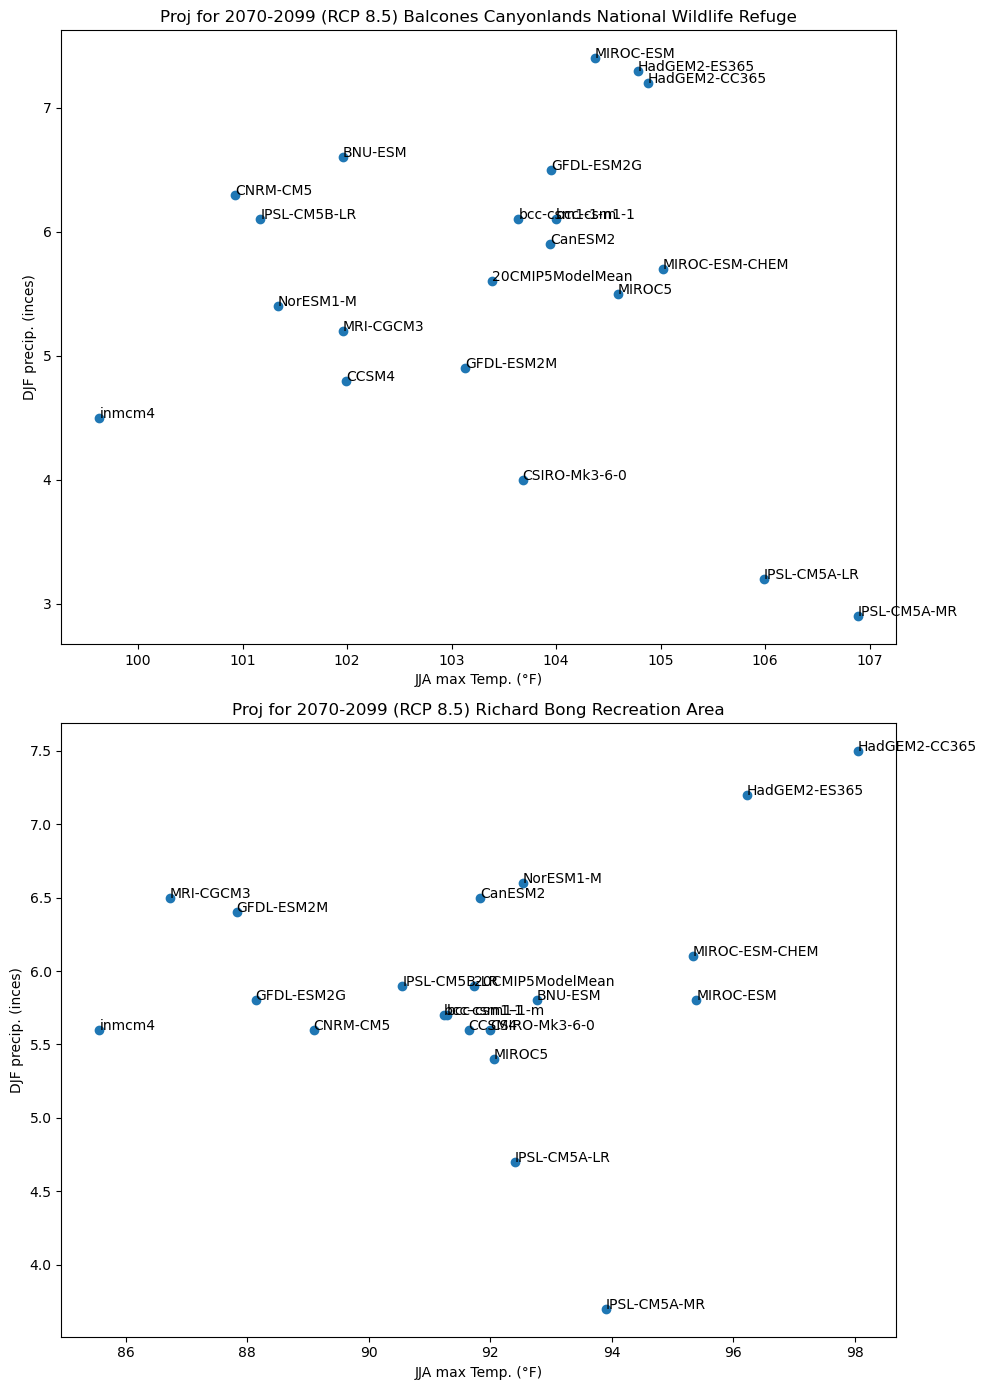

In [483]:
### plot futre scenarios for both sites
fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# First plot
axes[0].scatter(BalconesCanyonlands_model_df["X SCEN"], BalconesCanyonlands_model_df["Y SCEN"])
for x, y, label in zip(BalconesCanyonlands_model_df["X SCEN"], BalconesCanyonlands_model_df["Y SCEN"], BalconesCanyonlands_model_df["Model"]):
    axes[0].text(x, y, label)
axes[0].set_title("Proj for 2070-2099 (RCP 8.5) Balcones Canyonlands National Wildlife Refuge")
axes[0].set_xlabel("JJA max Temp. (°F)")
axes[0].set_ylabel("DJF precip. (inces)")

# Second plot
axes[1].scatter(RichardBongRecreationArea_model_df["X SCEN"], RichardBongRecreationArea_model_df["Y SCEN"])
for x, y, label in zip(RichardBongRecreationArea_model_df["X SCEN"], RichardBongRecreationArea_model_df["Y SCEN"], RichardBongRecreationArea_model_df["Model"]):
    axes[1].text(x, y, label)
axes[1].set_title("Proj for 2070-2099 (RCP 8.5) Richard Bong Recreation Area")
axes[1].set_xlabel("JJA max Temp. (°F)")
axes[1].set_ylabel("DJF precip. (inces)")

plt.tight_layout()
plt.show()

**Reflect and respond**: Choose at least 4 climate models that cover the range of possible future climate variability at your sites. Which models did you choose, and how did you make that decision?

Your response here (don't forget to cite the Climate Toolbox): 

We used the [Climate Futures Toolbox Future Climate Scattertool](https://climatetoolbox.org/tool/Future-Climate-Scatter) to get future scenrarios for both of our sites. 
These data can be downloaded from the website and are plotted above. 
We selected the models for the four combinations based on visual assessment and have listed them below for both sites.

Balcones Canyonlands National Wildlife Refuge:

-   Warm and wet -> HadGEM2-CC365
-   Warm and dry -> IPSL-CM5A-MR
-   Cold and wet -> BNU-ESM
-   Cold and dry -> inmcm4

Richard Bong Recreation Area

-   Warm and wet -> HadGEM2-CC365
-   Warm and dry -> IPSL-CM5A-MR
-   Cold and wet -> MRI-CGCM3
-   Cold and dry -> inmcm4


Citation: 

Hegewisch, K.C. and Abatzoglou, J.T..' Future Climate Scatter' web tool. Climate Toolbox (https://climatetoolbox.org/) accessed on [2026, March 3]

## STEP 2: Data access

### Step 2a: Soil data

The [POLARIS dataset](http://hydrology.cee.duke.edu/POLARIS/) is a
convenient way to uniformly access a variety of soil parameters such as
pH and percent clay in the US. It is available for a range of depths (in
cm) and split into 1x1 degree tiles.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download POLARIS data for a particular location, soil parameter,
and soil depth. Your function should account for the situation where
your site boundary crosses over multiple tiles, and merge the necessary
data together.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include soil parameters that will help you to
answer your scientific question. We recommend using a soil depth that
best corresponds with the rooting depth of your species.</p></div></div>

In [283]:
def getBuffer(site_gdf, buffer_size=0.025):
    """
    Buffer the site_gdf by a specified buffer size.
    site_gdf: GeoDataFrame containing the site geometry.
    buffer_size: The size of the buffer to apply (default is 0.025 degrees).
    
    Returns: A tuple representing the buffered bounds (xmin, ymin, xmax, ymax).
    """ 
    ### make a bounding box for the two sites and plot it on the map
    xmin, ymin, xmax, ymax = site_gdf.total_bounds

    ### initialize tiles to accumulate into 
    tiles = []

    ### buffer
    buffer = buffer_size
    bounds_buffered = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)

    return bounds_buffered

In [284]:
### Download and process soil data from the Polaris API for sites
def getPolarisSoilData(site_gdf, 
                       variable_name='ph',
                       depth_range=(100, 200)):
    """
    Get soil data from the Polaris API for a given site and variable.
    Merge downloaded tiles into a single raster and clip to the site boundary.
    site_gdf: A GeoDataFrame containing the geometry of the site.
    variable_name:  Default is 'ph', but can be set to any of the following variables:
                    silt - silt percentage, %
                    sand - sand percentage, %
                    clay - clay percentage, %
                    bd - bulk density, g/cm3
                    theta_s - saturated soil water content, m3/m3
                    theta_r - residual soil water content, m3/m3
                    ksat - saturated hydraulic conductivity, log10(cm/hr)
                    ph - soil pH in H2O, N/A
                    om - organic matter, log10(%)
                    lambda - pore size distribution index (brooks-corey), N/A
                    hb - bubbling pressure (brooks-corey), log10(kPa)
                    n - measure of the pore size distribution (van genuchten), N/A
                    alpha - scale parameter inversely proportional to mean pore diameter (van genuchten), log10(kPa-1)
    depth_range: Depth from surface, default is 100-200 cm, but can be set to any of the following ranges:
                 0-5 cm
                 5-15 cm
                 15-30 cm
                 30-60 cm
                 60-100 cm
                 100-200 cm
    """
    ### make a bounding box for the two sites and plot it on the map
    xmin, ymin, xmax, ymax = site_gdf.total_bounds

    ### initialize tiles to accumulate into 
    tiles = []

    # ### buffer
    # buffer = 0.025
    # bounds_buffered = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)
    bounds_buffered = getBuffer(site_gdf, buffer_size=0.025)

    ### loop 
    for lat_min in range(floor(ymin), ceil(ymax)):
        for lon_min in range(floor(xmin), ceil(xmax)):
            
            ### calculate max lt and lonf for tile 
            lat_max = lat_min + 1
            lon_max = lon_min + 1

            ### url for ph data 
            ph_url = (
                "http://hydrology.cee.duke.edu/POLARIS/PROPERTIES/v1.0"
                f"/{variable_name}/mean/{depth_range[0]}_{depth_range[1]}/"
                f"/lat{lat_min}{lat_max}_lon{lon_min}{lon_max}.tif"
            )

            ### open raster and append to list
            try:
                ph_tile = rxr.open_rasterio(ph_url, mask_and_scale=True).squeeze()
                #cropped_tile = ph_tile.rio.clip_box(*bounds_buffered)
                tiles.append(ph_tile)
                #tiles.append(cropped_tile)
            except Exception as e:
                print(f"Could not retrieve tile for lat {lat_min} to {lat_max} and lon {lon_min} to {lon_max}. Error: {e}")

    ### merge tiles into single raster
    if tiles:
        #merged_raster = rxrm.merge_arrays(tiles).rio.clip_box(*site_gdf.total_bounds)
        merged_raster = rxrm.merge_arrays(tiles).rio.clip_box(*bounds_buffered)
        #merged_raster = rxrm.merge_arrays(tiles)
        print("Successfully merged tiles into a single raster.")
        ### mask out nodata values
        #merged_raster = merged_raster.where(merged_raster != merged_raster.rio.nodata)
        return merged_raster
    else:    
        print("No tiles were retrieved, so merging was not performed.")

In [536]:
### get soil data for both sites
soil_ph_das = {
    # richard bong recreation area
    "RB": getPolarisSoilData(richard_bong_gdf, variable_name='ph', depth_range=(60, 100)), 
    # indiangrass wildlife sanctuary    
    "BC": getPolarisSoilData(balcones_canyonlands_gdf, variable_name='ph', depth_range=(60, 100)) 
}

Successfully merged tiles into a single raster.
Successfully merged tiles into a single raster.


In [206]:
# function to save an xarray.DataArray as a raster
def export_to_raster(data_array, raster_path, data_dir):
    """
    Export an xarray.DataArray to a raster file.
    data_array: The xarray.DataArray to export.
    raster_path: The original path of the raster (used to derive the output filename).
    data_dir: The directory where the output raster will be saved.

    returns: None
    """

    output_file = os.path.join(data_dir, os.path.basename(raster_path))
    data_array.rio.to_raster(output_file)

    print(f"Exported DataArray to {output_file}")

In [442]:
raster_richard_bong_path = os.path.join(wisconsin_IG.site_dir, 'ph_richard_bong.tif')

export_to_raster(soil_ph_das["RB"], raster_richard_bong_path, wisconsin_IG.site_dir)

Exported DataArray to /Users/markusjesswein/earth-analytics/data/habitat_suit/indiangrass_WI/ph_richard_bong.tif


In [485]:
raster_balcones_canyonlands_path = os.path.join(texas_IG.site_dir, 'ph_balcones_canyonlands.tif')

export_to_raster(soil_ph_das["BC"], raster_balcones_canyonlands_path, texas_IG.site_dir)

Exported DataArray to /Users/markusjesswein/earth-analytics/data/habitat_suit/indiangrass_TX/ph_balcones_canyonlands.tif


In [288]:
### function for customazible plots 
def plot_site(site_da, site_gdf, plots_dir, site_fig_name, plot_title, bar_label, plot_cmap, boundary_clr, tif_file =False):
    """
    Create custom site plot.

    site_da: xarray.DataArray containing input site raster.
    site_gdf: GeoDataFrame containing the boundary gdf.
    plots_dir: Directory where the plot will be saved.
    site_fig_name: A short name for the site.
    plot_title: Title for the plot.
    bar_label: Label for the colorbar.
    plot_cmap: Colormap to use for plotting the soil data.
    boundary_clr: Color to use for plotting the site boundaries.
    tif_file: indicate site file

    returns: matplotlib.pyplot.plot of the site with custom settings.
    """
    ### set up the figure 
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes()

    ### conditional
    if tif_file:
        site_da = rxr.open_rasterio(site_da, masked=True)

    ### plot data array values 
    site_plot = site_da.plot(
        cmap = plot_cmap, 
        cbar_kwargs={'label': bar_label})
    
    ### plot site boundaries
    site_gdf.boundary.plot(
        ax=plt.gca(),
        color=boundary_clr)
    
    plt.title(plot_title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    ### save the plot
    fig.savefig(f"{plots_dir}/{site_fig_name}.png", dpi=300)

    return site_plot
            


In [ ]:
# create path to plots, for me, the notebook path fits well
ph_plots_dir = os.path.join(notebook_path, 'soil', 'plots')
os.makedirs(ph_plots_dir, exist_ok=True )

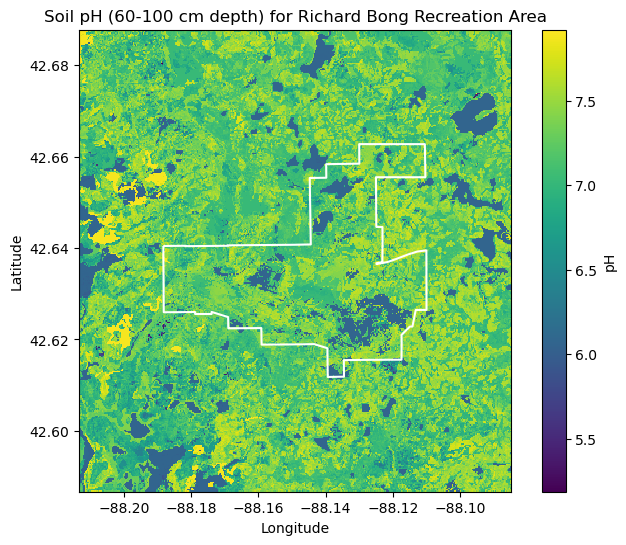

In [ ]:
richard_bong_plot = plot_site(site_da=soil_ph_das["RB"], 
                              site_gdf=richard_bong_gdf,
                              plots_dir=ph_plots_dir,
                              site_fig_name='ph_richard_bong',
                              plot_title='Soil pH (60-100 cm depth) for Richard Bong Recreation Area',
                              bar_label='pH',
                              plot_cmap='viridis',
                              boundary_clr='white')

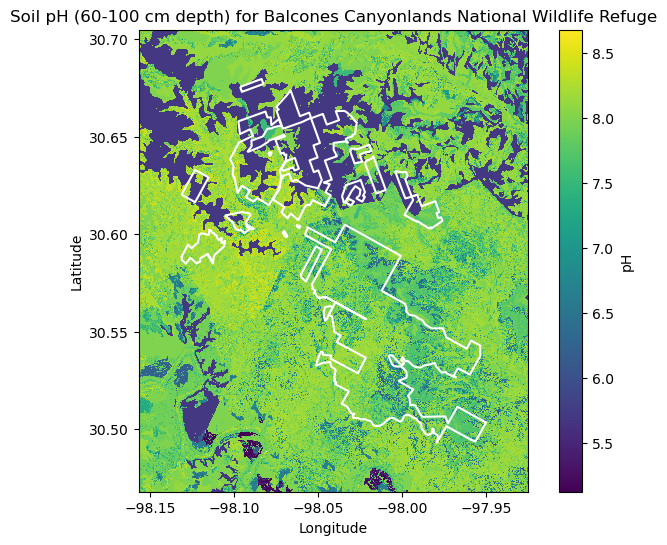

In [ ]:
balcones_canyonlands_plot = plot_site(site_da=soil_ph_das["BC"], 
                              site_gdf=balcones_canyonlands_gdf,
                              plots_dir=ph_plots_dir,
                              site_fig_name='ph_balcones_canyonlands',
                              plot_title='Soil pH (60-100 cm depth) for Balcones Canyonlands National Wildlife Refuge',
                              bar_label='pH',
                              plot_cmap='viridis',
                              boundary_clr='white')

### Step 2b: Topographic data

Depending on your species habitat needs/environmental parameters, you might be interested in elevation, slope, and/or aspect. You can access reliable elevation data from the [SRTM
dataset](https://www.earthdata.nasa.gov/data/instruments/srtm),
available through the [earthaccess
API](https://earthaccess.readthedocs.io/en/latest/quick-start/). Once you have elevation data, you can calculate slope and aspect.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download SRTM elevation data for a particular location and
calculate any additional topographic variables you need such as slope or
aspect.</p>
<p>Then, use loops to download and organize the rasters you will need to
complete this section. Include topographic parameters that will help you
to answer your scientific question.</p></div></div>

> **Warning**
>
> Be careful when computing the slope from elevation that the units of
> elevation match the projection units (e.g. meters and meters, not
> meters and degrees). You will need to project the SRTM data to
> complete this calculation correctly.

In [499]:
### make directory for topography data
elev_dir = os.path.join(notebook_path, 'topography')
os.makedirs(elev_dir, exist_ok=True)

### make subdir for the two sites 
richard_bong_topo_dir = os.path.join(elev_dir, 'richard_bong')
os.makedirs(richard_bong_topo_dir, exist_ok=True)

balcones_canyonlands_topo_dir = os.path.join(elev_dir, 'balcones_canyonlands')
os.makedirs(balcones_canyonlands_topo_dir, exist_ok=True)

In [215]:
earthaccess.login()

In [500]:
datasets = earthaccess.search_datasets(keyword = "SRTM DEM")
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

INFO:Datasets found: 50


ICRAF_AfSIS_AfrHySRTM Africa Soil Information Service (AfSIS): Hydrologically Corrected/Adjusted SRTM DEM (AfrHySRTM)
NASADEM_SHHP NASADEM SRTM-only Height and Height Precision Mosaic Global 1 arc second V001
NASADEM_SIM NASADEM SRTM Image Mosaic Global 1 arc second V001
NASADEM_SSP NASADEM SRTM Subswath Global 1 arc second V001
USGS_OFR_2004_1322 Digital Shaded-Relief Map of Venezuela
C_Pools_Fluxes_CONUS_1837 CMS: Terrestrial Carbon Stocks, Emissions, and Fluxes for Conterminous US, 2001-2016
SRTMGL1 NASA Shuttle Radar Topography Mission Global 1 arc second V003
GEDI02_B GEDI L2B Canopy Cover and Vertical Profile Metrics Data Global Footprint Level V002
NASADEM_HGT NASADEM Merged DEM Global 1 arc second V001
SRTMGL3 NASA Shuttle Radar Topography Mission Global 3 arc second V003
GEDI01_B GEDI L1B Geolocated Waveform Data Global Footprint Level V002
NASADEM_NC NASADEM Merged DEM Global 1 arc second nc V001
SRTMGL1N NASA Shuttle Radar Topography Mission Global 1 arc second number V003
S

In [555]:
### function to get srtm topo data for a site, if it doesn't already exist in the topo dir
def getSRTMTopoData(site_gdf,
                    topo_dir):
    """
    Get SRTM topography data for a given site. 
    If the data already exists in the specified directory, it will be loaded from there. 
    Otherwise, it will be downloaded from Earth Access, unzipped, and processed to extract aspect and slope information.

    site_gdf: A GeoDataFrame containing the geometry of the site.
    topo_dir: The directory where the topography data will be stored.

    returns: A dictionary containing the cropped topography data, aspect, and slope as xarray.DataArrays.
    """

    site_pattern = os.path.join(topo_dir, '*.hgt.zip')

    # ### make a bounding box for the two sites and plot it on the map
    # xmin, ymin, xmax, ymax = site_gdf.total_bounds

    # ### add buffer 
    # buffer = 0.025
    # bounds_buffered = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)
    bounds_buffered = getBuffer(site_gdf, buffer_size=0.025)

    ### look for files in the topo dir
    if not glob(site_pattern):
        ### search for data
        site_srtm_search = earthaccess.search_data(
            short_name = "SRTMGL3",
            bounding_box = bounds_buffered
        )
        ### download data
        earthaccess.download(site_srtm_search, 
                             topo_dir)
        
        ### unzip data
        for zip_file in glob(site_pattern):
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(topo_dir)
            print(f"Unzipped {zip_file} to {topo_dir}")
        #return site_srtm_results
        
    else: 
        print(f"SRTM data already exists in {topo_dir}, skipping download.")

    ### open the tile, crop it to the buffered bounds and return it as a data array
    srtm_da_list = []
    srtm_paths = glob(os.path.join(topo_dir, '*.hgt'))
    #srtm_path = glob(os.path.join(topo_dir, '*.hgt'))[0]
    #tile_da = rxr.open_rasterio(srtm_path, masked_and_scale=True).squeeze()
    #cropped_tile = tile_da.rio.clip_box(*bounds_buffered)
    for srtm_path in srtm_paths:
        tile_da = rxr.open_rasterio(srtm_path, masked_and_scale=True).squeeze()
        tmp_cropped_tile = tile_da.rio.clip_box(*bounds_buffered)
        srtm_da_list.append(tmp_cropped_tile)

    ### merge all srtm data arrays
    cropped_tile = rxrm.merge_arrays(srtm_da_list)

    ### get aspect
    aspect_tile = xrspatial.aspect(cropped_tile)
    ### only positive values
    aspect_tile = aspect_tile.where(aspect_tile >= 0)

    ### get slope
    cropped_reporjected = cropped_tile.rio.reproject("EPSG:5070")
    slope_tile = xrspatial.slope(cropped_reporjected)
    slope_tile_4326 = slope_tile.rio.reproject("EPSG:4326")
    slope_tile_4326 = slope_tile_4326.where((slope_tile_4326 > 0) & (slope_tile_4326 < 70))
    
    return {"elevation": cropped_tile, "aspect": aspect_tile, "slope": slope_tile_4326}
    


In [556]:
### get toto data for both sites
topo_das = {
    # richard bong recreation area
    "RB": getSRTMTopoData(richard_bong_gdf, richard_bong_topo_dir), 
    # indiangrass wildlife sanctuary    
    "BC": getSRTMTopoData(balcones_canyonlands_gdf, balcones_canyonlands_topo_dir) 
}

SRTM data already exists in /Users/markusjesswein/Documents/Projects/Earth_Analytics_Data_Science/spring-03-habitat-suitability-climate-change-MarJess/topography/richard_bong, skipping download.
SRTM data already exists in /Users/markusjesswein/Documents/Projects/Earth_Analytics_Data_Science/spring-03-habitat-suitability-climate-change-MarJess/topography/balcones_canyonlands, skipping download.


In [563]:
# create path to plots, for me, the notebook path fits well
topo_plots_dir = os.path.join(notebook_path, 'topography', 'plots')
os.makedirs(topo_plots_dir, exist_ok=True )

In [568]:
topo_das["BC"].keys()

dict_keys(['elevation', 'aspect', 'slope'])

### Topography plots for both sites 

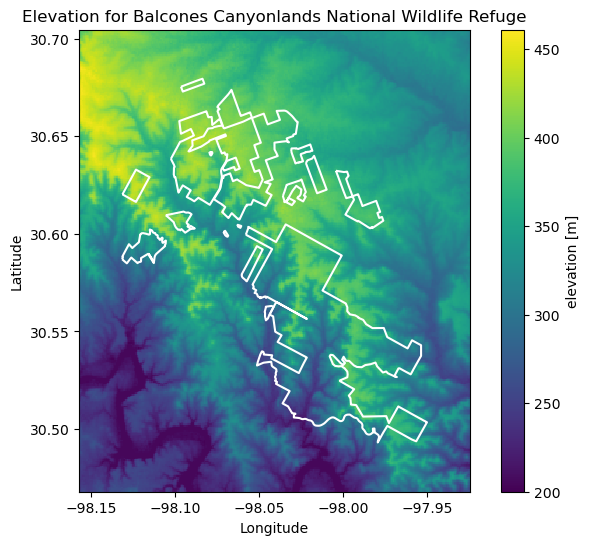

In [571]:
balcones_canyonlands_elev_plot = plot_site(site_da=topo_das["BC"]["elevation"], 
                                site_gdf=balcones_canyonlands_gdf,
                                plots_dir=topo_plots_dir,
                                site_fig_name='elevation_balcones_canyonlands',
                                plot_title='Elevation for Balcones Canyonlands National Wildlife Refuge',
                                bar_label='elevation [m]',
                                plot_cmap='viridis',
                                boundary_clr='white')

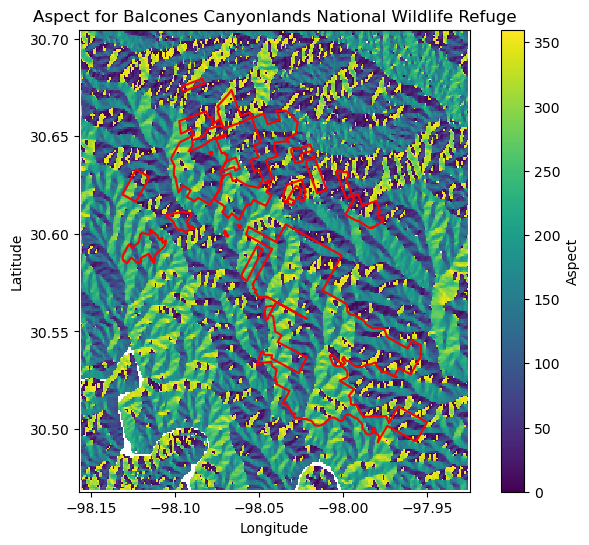

In [572]:
balcones_canyonlands_aspect_plot = plot_site(site_da=topo_das["BC"]["aspect"], 
                                site_gdf=balcones_canyonlands_gdf,
                                plots_dir=topo_plots_dir,
                                site_fig_name='aspect_balcones_canyonlands',
                                plot_title='Aspect for Balcones Canyonlands National Wildlife Refuge',
                                bar_label='Aspect',
                                plot_cmap='viridis',
                                boundary_clr='red')

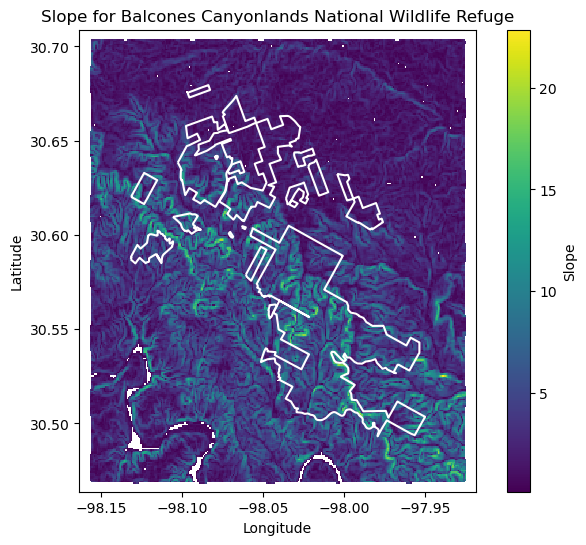

In [573]:
balcones_canyonlands_slope_plot = plot_site(site_da=topo_das["BC"]["slope"], 
                                site_gdf=balcones_canyonlands_gdf,
                                plots_dir=topo_plots_dir,
                                site_fig_name='slope_balcones_canyonlands',
                                plot_title='Slope for Balcones Canyonlands National Wildlife Refuge',
                                bar_label='Slope',
                                plot_cmap='viridis',
                                boundary_clr='white')

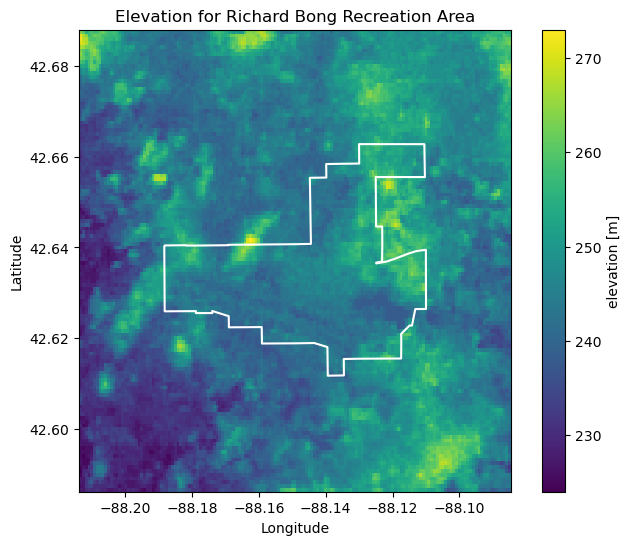

In [575]:
richard_bong_elev_plot = plot_site(site_da=topo_das["RB"]["elevation"], 
                                site_gdf=richard_bong_gdf,
                                plots_dir=topo_plots_dir,
                                site_fig_name='elevation_richard_bong',
                                plot_title='Elevation for Richard Bong Recreation Area',
                                bar_label='elevation [m]',
                                plot_cmap='viridis',
                                boundary_clr='white')

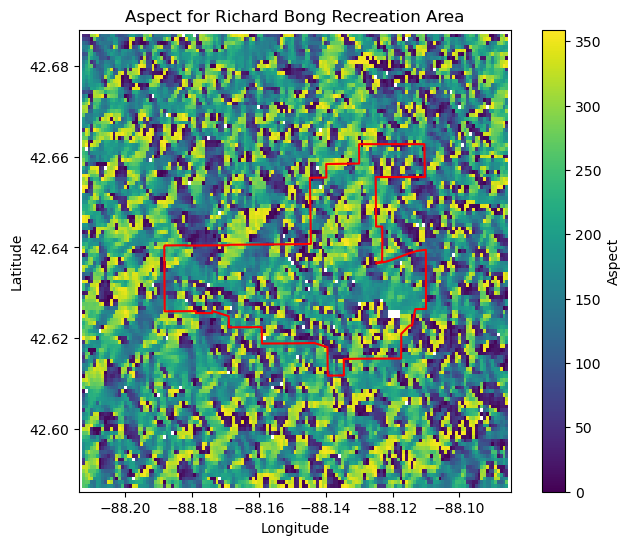

In [576]:
richard_bong_aspect_plot = plot_site(site_da=topo_das["RB"]["aspect"], 
                                site_gdf=richard_bong_gdf,
                                plots_dir=topo_plots_dir,
                                site_fig_name='aspect_richard_bong',
                                plot_title='Aspect for Richard Bong Recreation Area',
                                bar_label='Aspect',
                                plot_cmap='viridis',
                                boundary_clr='red')

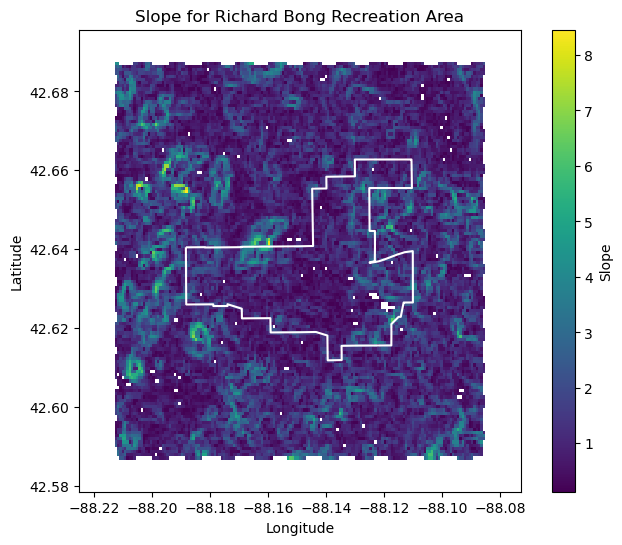

In [577]:
richard_bong_slope_plot = plot_site(site_da=topo_das["RB"]["slope"], 
                                site_gdf=richard_bong_gdf,
                                plots_dir=topo_plots_dir,
                                site_fig_name='slope_richard_bong',
                                plot_title='Slope for Richard Bong Recreation Area',
                                bar_label='Slope',
                                plot_cmap='viridis',
                                boundary_clr='white')

### Step 2c: Climate model data

You can use MACAv2 data for historical and future climate data. Be sure
to compare at least two 30-year time periods (e.g. historical vs. 10
years in the future) for at least four of the CMIP models. Overall, you
should be downloading at least 8 climate rasters for each of your sites,
for a total of 16. **You will *need* to use loops and/or functions to do
this cleanly!**.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Write a <strong>function with a numpy-style docstring</strong> that
will download MACAv2 data for a particular climate model, emissions
scenario, spatial domain, and time frame. Then, use loops to download
and organize the 16+ rasters you will need to complete this section. The
<a
href="http://thredds.northwestknowledge.net:8080/thredds/reacch_climate_CMIP5_macav2_catalog2.html">MACAv2
dataset is accessible from their Thredds server</a>. Include an
arrangement of sites, models, emissions scenarios, and time periods that
will help you to answer your scientific question.</p></div></div>

In [314]:
maca_dir = os.path.join(data_dir, 'maca_dir')
os.makedirs(maca_dir, exist_ok=True)

maca_pattern = os.path.join(maca_dir, '*.nc')

In [315]:
def convert_temperature_to_celsius(da):
    """
    Convert temperature from Kelvin to Celsius in an xarray.DataArray.
    da: The xarray.DataArray containing temperature data in Kelvin.

    returns: An xarray.DataArray with temperature converted to Celsius.
    """
    return da - 273.15


def convert_longitude(longitude):
    """
    Convert longitude values from 0-360 to -180 to 180 in an xarray.DataArray.
    da: The xarray.DataArray containing longitude data.

    returns: An xarray.DataArray with longitude values converted to the -180 to 180 range.
    """
    return (longitude -360) if longitude > 180 else longitude

In [369]:
def getMACADateRanges(start_year, end_year):
    """
    Generate a list of date ranges for MACA data based on the provided start and end years.
    start_year: The starting year for the date ranges.
    end_year: The ending year for the date ranges.  
    """
    intervals = []

    # historical
    intervals += [(y, y + 4) for y in range(1950, 2001, 5)]

    # transition
    intervals.append((2005, 2005))

    # future
    intervals += [(y, y + 4) for y in range(2006, 2096, 5)]

    # final
    intervals.append((2096, 2099))

    return [
        f"{s}_{e}"
        for s, e in intervals
        if s <= end_year and e >= start_year
    ]

In [407]:
def processMACAData(site_name,
                    site_gdf, 
                    date_ranges, 
                    models,
                    rcp_value,
                    variable_names, 
                    maca_dir):
        
        results_list = []

        for date_range in date_ranges:
                for model in models:
                        for variable_name in variable_names:
                                maca_path = os.path.join(maca_dir, f'maca_{model}_{site_name}_{variable_name}_{rcp_value}_{date_range}_CONUS_monthly.nc')

                                maca_url = (
                                        "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
                                        "/MACAV2"
                                        f"/{model}"
                                        f"/macav2metdata_{variable_name}"
                                        f"_{model}_r1i1p1"
                                        f"_{rcp_value}"
                                        f"_{date_range}_CONUS"
                                        "_monthly.nc"
                                        )
                                
                                if not os.path.exists(maca_path):
                                        maca_da = xr.open_dataset(maca_url, engine="netcdf4").squeeze()
                                        maca_da.to_netcdf(maca_path)
                                        print(f"Downloaded MACA data for {site_name} and saved to {maca_path}")
                                else:
                                        print(f"MACA data for {site_name} already exists at {maca_path}, skipping download.")
                                
                                maca_da = xr.open_dataset(maca_path).squeeze()

                                site_rpj = site_gdf.to_crs(maca_da.rio.crs)

                                maca_da = maca_da.assign_coords(
                                        lon= ("lon", [convert_longitude(lon) for lon in maca_da.lon.values])
                                        )
                                
                                maca_da = maca_da.rio.set_spatial_dims(
                                        x_dim="lon", 
                                        y_dim="lat"
                                        )
                                maca_da_cropped = maca_da.rio.clip_box(*site_rpj.total_bounds, allow_one_dimensional_raster=True)

                                result = dict(
                                        site_name = site_name,
                                        climate_model = model,
                                        variable_name = variable_name,
                                        data_range = date_range,
                                        da = maca_da_cropped
                                        )
                                
                                results_list.append(result)

        return results_list



Indiangrass Wildlife Sanctuary:

-   Warm and wet -> HadGEM2-CC365
-   Warm and dry -> IPSL-CM5A-MR
-   Cold and wet -> BNU-ESM
-   Cold and dry -> inmcm4

Richard Bong Recreation Area

-   Warm and wet -> HadGEM2-CC365
-   Warm and dry -> IPSL-CM5A-MR
-   Cold and wet -> MRI-CGCM3
-   Cold and dry -> inmcm4

In [526]:
dates_ranges_historical = getMACADateRanges(1970, 1999) 
dates_ranges_future = getMACADateRanges(2071, 2099)

richard_bong_models = ["HadGEM2-CC365", "IPSL-CM5A-MR", "MRI-CGCM3", "inmcm4"]
balcones_canyonlands_models = ["HadGEM2-CC365", "IPSL-CM5A-MR", "BNU-ESM", "inmcm4"]


In [527]:
richard_bing_hist_pr = processMACAData("RB",
                                        richard_bong_gdf, 
                                        dates_ranges_historical, 
                                        richard_bong_models,
                                        "historical", 
                                        ["pr"], 
                                        maca_dir)

richard_bing_future_pr = processMACAData("RB",
                                        richard_bong_gdf, 
                                        dates_ranges_future, 
                                        richard_bong_models,
                                        "rcp85", 
                                        ["pr"], 
                                        maca_dir)

balcones_canyonlands_hist_pr = processMACAData("BC",
                                        balcones_canyonlands_gdf, 
                                        dates_ranges_historical, 
                                        balcones_canyonlands_models,
                                        "historical", 
                                        ["pr"], 
                                        maca_dir)

balcones_canyonlands_future_pr = processMACAData("BC",
                                        balcones_canyonlands_gdf, 
                                        dates_ranges_future, 
                                        balcones_canyonlands_models,
                                        "rcp85", 
                                        ["pr"], 
                                        maca_dir)

MACA data for RB already exists at /Users/markusjesswein/earth-analytics/data/habitat_suit/maca_dir/maca_HadGEM2-CC365_RB_pr_historical_1970_1974_CONUS_monthly.nc, skipping download.
MACA data for RB already exists at /Users/markusjesswein/earth-analytics/data/habitat_suit/maca_dir/maca_IPSL-CM5A-MR_RB_pr_historical_1970_1974_CONUS_monthly.nc, skipping download.
MACA data for RB already exists at /Users/markusjesswein/earth-analytics/data/habitat_suit/maca_dir/maca_MRI-CGCM3_RB_pr_historical_1970_1974_CONUS_monthly.nc, skipping download.
MACA data for RB already exists at /Users/markusjesswein/earth-analytics/data/habitat_suit/maca_dir/maca_inmcm4_RB_pr_historical_1970_1974_CONUS_monthly.nc, skipping download.
MACA data for RB already exists at /Users/markusjesswein/earth-analytics/data/habitat_suit/maca_dir/maca_HadGEM2-CC365_RB_pr_historical_1975_1979_CONUS_monthly.nc, skipping download.
MACA data for RB already exists at /Users/markusjesswein/earth-analytics/data/habitat_suit/maca_d

In [ ]:
def calc_mean_precip(das, months_range=None):
    """
    Calculate the mean annual precipitation from a list of xarray.DataArrays.

    Parameters
    ----------
    das : list[xr.DataArray]
        List of precipitation DataArrays with a time dimension.
    months_range : list[int], optional
        Months to include (e.g., [4,5,6,7,8,9] for growing season).

    Returns
    -------
    xr.DataArray
        Mean annual precipitation.
    """

    # combine all arrays along time
    combined = xr.concat(das, dim="time").sortby("time")

    # select months if requested
    if months_range is not None:
        combined = combined.sel(time=combined.time.dt.month.isin(months_range))

    # annual totals
    annual = combined.resample(time="YE").sum()

    # mean across years
    result = annual.mean(dim="time")

    # ensure spatial metadata
    result = result.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

    if result.rio.crs is None:
        result = result.rio.write_crs("EPSG:4326")

    return result


def site_seasonal_precip(site_results, 
                         site_name,
                         models, 
                         months_range=None):
    """
    Calculate seasonal mean precipitation for a site from processed MACA data.

    Parameters
    ----------
    site_results : list[dict]
        List of dictionaries containing processed MACA data for a site.
    months_range : list[int], optional
        Months to include in the seasonal calculation (e.g., [4,5,6,7,8,9] for growing season).

    Returns
    -------
    dict
        Dictionary with keys as (model, data_range) and values as mean precipitation DataArrays.
    """

    mean_precip = {}

    for model in models:
        pr_das = [
            r['da'] for r in site_results
                if r['site_name'] == site_name
                and r['climate_model'] == model
                and r['variable_name'] == 'pr'
            ]

        tmp_mean_precip = calc_mean_precip(pr_das, months_range=months_range)

        mean_precip[model] = tmp_mean_precip.precipitation

    return mean_precip



In [538]:
climate_das = {
    "RB": {
        "models" : richard_bong_models,
        # hist is 1970 to 1999
        "hist": site_seasonal_precip(richard_bing_hist_pr, "RB", richard_bong_models),
        # future is 2071 to 2099
        "future": site_seasonal_precip(richard_bing_future_pr, "RB", richard_bong_models)
    },
    "BC": {
        "models" : balcones_canyonlands_models,
        # hist is 1970 to 1999
        "hist": site_seasonal_precip(balcones_canyonlands_hist_pr, "BC", balcones_canyonlands_models),
        # future is 2071 to 2099
        "future": site_seasonal_precip(balcones_canyonlands_future_pr, "BC", balcones_canyonlands_models)
    }
}

<Axes: title={'center': 'crs = 0, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

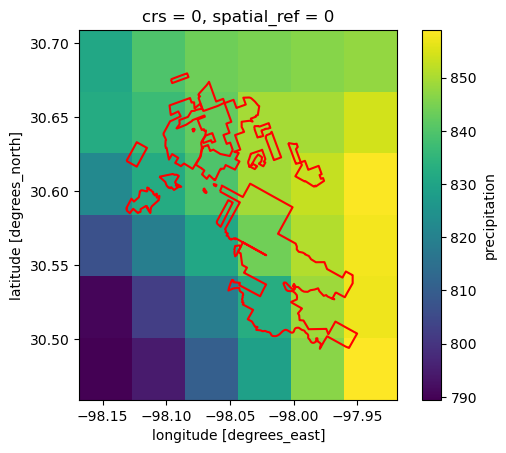

In [532]:
climate_das["BC"]["hist"]['HadGEM2-CC365'].plot()
balcones_canyonlands_gdf.boundary.plot(
    ax=plt.gca(),
    color='red')

In [ ]:
### Download climate data


**Reflect and respond**: Make sure to include a description of the climate data and how you selected your models. Include a citation of the MACAv2 data.

Your response here:

## STEP 3: Harmonize data
To use all your environmental and climate data layers together, you need to harmonize the different rasters you've downloaded and processed. 

As a first step, make sure that the grids for all the rasters match each other. Check out the <a href="https://corteva.github.io/rioxarray/stable/examples/reproject_match.html#Reproject-Match"><code>ds.rio.reproject_match()</code> method</a> from <code>rioxarray</code>. Make sure to use the data source that has the highest resolution as a template!</p></div></div>

> **Warning**
>
> If you are reprojecting data (as you need to here), the order of
> operations is important! Recall that reprojecting will typically tilt
> your data, leaving narrow sections of the data at the edge blank.
> However, to reproject efficiently it is best for the raster to be as
> small as possible before performing the operation. We recommend the
> following process:
>
>     1. Crop the data, leaving a buffer around the final boundary
>     2. Reproject to match the template grid (this will also crop any leftovers off the image)

In [534]:
topo_das.keys()
soil_ph_das.keys()
climate_das

dict_keys(['RB', 'BC'])

In [546]:
climate_das["BC"].keys()

dict_keys(['models', 'hist', 'future'])

In [547]:
def harmonize_das(site_name, site_gdf, soil_ph_das, topo_das, climate_das):
    """
    Harmonize the coordinate reference systems and spatial dimensions of topography, soil, and climate DataArrays for a given site.

    Parameters
    ----------
    site_name : str
        Short name for the site (e.g., "RB" for Richard Bong).
    site_gdf : gpd.GeoDataFrame
        GeoDataFrame containing the geometry of the site.
    soil_ph_das : dict 
        Dictionary containing soil pH DataArrays for each site. 
    topo_das : dict
        Dictionary containing topography DataArrays for each site. 
    climate_das : dict
        Dictionary containing climate DataArrays for each site, organized by historical and future scenarios.
    
    Returns
    -------
    """
    climate_models = climate_das[site_name]["models"]

    ### define the boundaries 
    site_bounds = tuple(site_gdf.total_bounds)

    ### ass a small buffer 
    buffer = 0.025
    (xmin, ymin, xmax, ymax) = site_bounds

    ### buffer bounding box
    site_buffer = (xmin - buffer,
                            ymin - buffer,
                            xmax + buffer,
                            ymax + buffer)
    
    ### reference
    ref_da = soil_ph_das[site_name]
    harmonized_soil = ref_da

    ### first harmonize topo data
    harmonized_topo = {}
    for key in topo_das[site_name].keys():
        ### crop the data 
        cropped_da = topo_das[site_name][key].rio.clip_box(*site_buffer)
        ### reproject and match 
        reproj_da = (cropped_da.rio.reproject_match(ref_da))
        ### add it to the list 
        harmonized_topo[key] = reproj_da

    ### harminize climate data
    harmonized_climate = {}
    for model in climate_models:
        cropped_hist_da = climate_das[site_name]["hist"][model].rio.clip_box(*site_buffer)
        cropped_future_da = climate_das[site_name]["future"][model].rio.clip_box(*site_buffer)
        ### reproject and match 
        reproj_hist_da = cropped_hist_da.rio.reproject_match(ref_da)
        reproj_future_da = cropped_future_da.rio.reproject_match(ref_da)
        ### add to harmonized climate dictionary
        harmonized_climate[model] = {
            "hist": reproj_hist_da,
            "future": reproj_future_da
        }

    return {"soil": harmonized_soil, "topo": harmonized_topo, "climate": harmonized_climate}    
        

In [562]:
richard_bing_haromonized = harmonize_das("RB", richard_bong_gdf, soil_ph_das, topo_das, climate_das)
balcones_canyonlands_haromonized = harmonize_das("BC", balcones_canyonlands_gdf, soil_ph_das, topo_das, climate_das)

In [302]:
### add a name to the arrazs for the one site 
ph_richard_bong.name = "RB soil ph"
topo_richard_bong["topo"].name = "RB elevation"
topo_richard_bong["aspect"].name = "RB aspect"
topo_richard_bong["slope"].name = "RB slope"


In [303]:
### list of layers
richard_bong_list = [
    ph_richard_bong,
    topo_richard_bong["topo"],
    topo_richard_bong["slope"],
    topo_richard_bong["aspect"]
]

### define the boundaries 
richard_bong_bounds = tuple(richard_bong_gdf.total_bounds)

### ass a small buffer 
buffer = 0.025
(rb_xmin, rb_ymin, rb_xmax, rb_ymax) = richard_bong_bounds

### buffer bounding box
richard_bong_buffer = (rb_xmin - buffer,
                       rb_ymin - buffer,
                       rb_xmax + buffer,
                       rb_ymax + buffer)

In [304]:
### check out pre-cropped boundaries 
print(ph_richard_bong.rio.bounds())
print(topo_richard_bong["topo"].rio.bounds())


(-88.21333333334076, 42.58666666667057, -88.08472222223087, 42.687777777780724)
(-88.21375, 42.58625, -88.08458333333333, 42.687916666666666)


In [309]:
### empty list fro cropped and reprojected DAs 
reproj_da_list = []

### loop through DAs 
for da in richard_bong_list:

    ### if RB is in the name, do this 
    if 'RB' in da.name:

        ### crop the data 
        cropped_da = da.rio.clip_box(*richard_bong_buffer)
        ### reproject and match 
        reproj_da = (cropped_da.rio.reproject_match(ph_richard_bong))

        ### add it to the list 
        reproj_da_list.append(reproj_da)


In [310]:
print(ph_richard_bong.rio.bounds())
print(reproj_da_list[1].rio.bounds())

(-88.21333333334076, 42.58666666667057, -88.08472222223087, 42.687777777780724)
(-88.21333333334076, 42.58666666667057, -88.08472222223087, 42.687777777780724)


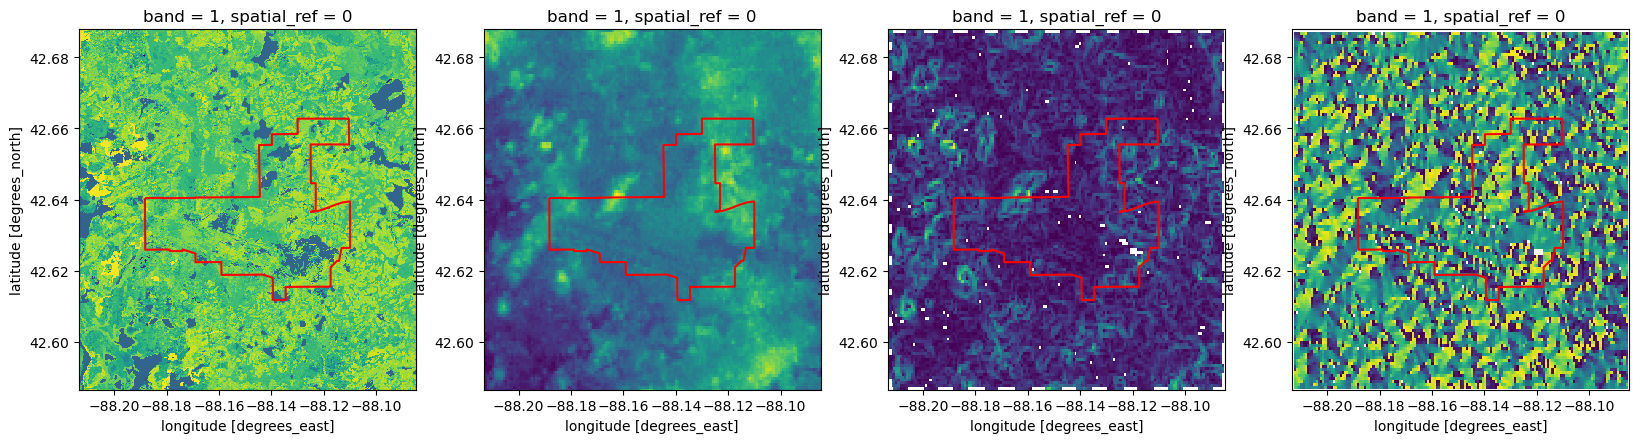

In [311]:
fig, axes = plt.subplots(1, len(reproj_da_list), figsize=(5*len(reproj_da_list),5))

if len(reproj_da_list) == 1:
    axes = [axes]

for ax, data in zip(axes, reproj_da_list):

    if data.ndim == 3:
        data = data.squeeze()

    data.plot(ax=ax, cmap='viridis', add_colorbar=False)

    richard_bong_gdf.boundary.plot(ax=ax, color='red')

In [5]:
### Align the grids of the different data layers

## STEP 4: Develop a fuzzy logic model

A fuzzy logic model is one that is built on expert knowledge rather than
training data. You may wish to use the
[`scikit-fuzzy`](https://pythonhosted.org/scikit-fuzzy/) library, which
includes many utilities for building this sort of model. In particular,
it contains a number of **membership functions** which can convert your
data into values from 0 to 1 using information such as, for example, the
maximum, minimum, and optimal values for soil pH.

To train a fuzzy logic habitat suitability model:</p>
<pre><code>1. Find the optimal values for your species for each variable you are using (e.g. soil pH, slope, and current annual precipitation). 
2. For each **digital number** in each raster, assign a **continuous** value from 0 to 1 for how close that grid square/pixel is to the optimum range (1 = optimal, 0 = incompatible). 
3. Combine your layers by multiplying them together. This will give you a single suitability number for each grid square.
4. Optionally, you may apply a suitability threshold to make the most suitable areas pop on your map.</code></pre></div></div>

> **Tip**
>
> If you use mathematical operators on a raster in Python, it will
> automatically perform the operation for every number in the raster.
> This type of operation is known as a **vectorized** function. **DO NOT
> DO THIS WITH A LOOP!**. A vectorized function that operates on the
> whole array at once will be much easier and faster.

In [6]:
### Create fuzzy logic model for habitat suitability

## STEP 5: Present your results
Generate some plots that show your key findings of habitat suitability in your study sites across the different time periods and climate models. Don’t forget to interpret your plots!

In [7]:
### Create plots

Interpret your plots here: